In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 优先使用 DejaVu Sans（对符号支持较好），其次用黑体
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False  # 确保负号正常显示

# 定义发动机转速范围：600到4000转，步长10
n = np.arange(600, 4001, 10)

# 车辆基础参数
m = 3880  # 整车质量，单位：kg
g = 9.8  # 重力加速度，单位：m/s²
G = m * g  # 车辆重力，单位：N
yitaT = 0.85  # 传动系统效率，无量纲
r = 0.367  # 车轮半径，单位：m
f = 0.013  # 滚动阻力系数，无量纲
CdA = 2.77  # 空气阻力系数×迎风面积，单位：m²
i0 = 5.83  # 主减速器传动比，无量纲
If = 0.218  # 飞轮转动惯量，单位：kg·m²
Iw1, Iw2 = 1.798, 3.598  # 前轮和后轮转动惯量，单位：kg·m²
L = 3.2  # 轴距，单位：m
a = 1.947  # 质心到前轴距离，单位：m
hg = 0.9  # 质心高度，单位：m

# 各挡位传动比（Ⅰ到Ⅴ档）
ig = np.array([5.56, 2.769, 1.644, 1.00, 0.793])

# 计算发动机转矩（多项式拟合公式，单位：N·m）
Tq = -19.313 + 295.27 * (n / 1000) - 165.44 * (n / 1000) ** 2 + \
     40.874 * (n / 1000) ** 3 - 3.8445 * (n / 1000) ** 4

# 计算滚动阻力（单位：N）
Ff = G * f

# 分挡位计算驱动力
Ft1 = Tq * ig[0] * i0 * yitaT / r  # Ⅰ档驱动力
Ft2 = Tq * ig[1] * i0 * yitaT / r  # Ⅱ档驱动力
Ft3 = Tq * ig[2] * i0 * yitaT / r  # Ⅲ档驱动力
Ft4 = Tq * ig[3] * i0 * yitaT / r  # Ⅳ档驱动力
Ft5 = Tq * ig[4] * i0 * yitaT / r  # Ⅴ档驱动力

# 分挡位计算车速（单位：km/h）
ua1 = 0.377 * r * n / (ig[0] * i0)  # Ⅰ档车速
ua2 = 0.377 * r * n / (ig[1] * i0)  # Ⅱ档车速
ua3 = 0.377 * r * n / (ig[2] * i0)  # Ⅲ档车速
ua4 = 0.377 * r * n / (ig[3] * i0)  # Ⅳ档车速
ua5 = 0.377 * r * n / (ig[4] * i0)  # Ⅴ档车速

# 定义绘图用的车速范围（0到120km/h，步长5）
ua = np.arange(0, 121, 5)

# 计算空气阻力（单位：N）
Fw = CdA * ua ** 2 / 21.15

# 计算总行驶阻力（滚动阻力+空气阻力，单位：N）
Fz = Ff + Fw

# 绘制平衡图
plt.figure(figsize=(10, 6))  # 创建画布
plt.plot(ua1, Ft1, label='Ft1（Ⅰ档）')
plt.plot(ua2, Ft2, label='Ft2（Ⅱ档）')
plt.plot(ua3, Ft3, label='Ft3（Ⅲ档）')
plt.plot(ua4, Ft4, label='Ft4（Ⅳ档）')
plt.plot(ua5, Ft5, label='Ft5（Ⅴ档）')
plt.plot(ua, Fz, label='Ff+Fw（总阻力）', linewidth=2)  # 加粗阻力曲线

# 设置图表属性
plt.title('驱动力-行驶阻力平衡图')
plt.xlabel('车速ua (km/h)')
plt.ylabel('力F (N)')
plt.legend()  # 显示图例
plt.grid(True, linestyle='--', alpha=0.7)  # 添加网格
plt.xlim(0, 120)  # 设置x轴范围
plt.ylim(0, 12000)  # 设置y轴范围

# 保存并显示图表
plt.savefig('驱动力平衡图_自定义.png', dpi=300, bbox_inches='tight')
plt.close()

In [2]:
# 计算Ⅴ档驱动力和车速（用于最高车速求解）
Ft5 = Tq * ig[4] * i0 * yitaT / r
ua5 = 0.377 * r * n / (ig[4] * i0)

# 定义绘图用速度范围
ua = np.arange(0, 121, 5)
Fw = CdA * ua ** 2 / 21.15  # 空气阻力
Fz = Ff + Fw  # 总阻力

# 创建局部画布（仅绘制Ⅴ档和阻力曲线）
plt.figure(figsize=(8, 5))
plt.plot(ua5, Ft5, label='Ft5（Ⅴ档驱动力）')
plt.plot(ua, Fz, label='Ff+Fw（总阻力）', linewidth=2)

# 寻找曲线交点（最高车速）
min_diff = np.inf
intersection_ua = 0
intersection_F = 0

for u in ua:
    # 线性插值获取对应车速的驱动力
    idx = np.searchsorted(ua5, u, side='left')
    if idx >= len(ua5):
        idx = len(ua5) - 1
    ft_interp = np.interp(u, ua5, Ft5)
    diff = abs(ft_interp - Fz[ua.tolist().index(u)])

    # 更新最小差值和交点坐标
    if diff < min_diff:
        min_diff = diff
        intersection_ua = u
        intersection_F = ft_interp

# 标注交点
plt.scatter(intersection_ua, intersection_F, color='red', marker='o', zorder=5)
plt.annotate(
    f'最高车速：{intersection_ua:.2f} km/h',
    xy=(intersection_ua, intersection_F),
    xytext=(20, -20),
    textcoords='offset points',
    arrowprops=dict(facecolor='black', arrowstyle='->')
)

# 设置图表属性
plt.title('Ⅴ档驱动力-阻力平衡（最高车速分析）')
plt.xlabel('车速ua (km/h)')
plt.ylabel('力F (N)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 保存图表（自定义样式）
plt.savefig('最高车速分析图_自定义.png', dpi=300)
plt.close()

In [7]:
# 计算最大爬坡度（Ⅰ档）
Ft1 = Tq * ig[0] * i0 * yitaT / r  # Ⅰ档驱动力
ua1 = 0.377 * r * n / (ig[0] * i0)  # Ⅰ档车速
Fw1 = CdA * ua1 ** 2 / 21.15  # Ⅰ档空气阻力
Fz1 = Ff + Fw1  # Ⅰ档总阻力
Ftt = Ft1 - Fz1  # 剩余驱动力（用于爬坡）

# 计算剩余驱动力与车重的最大比值
max_ratio = np.max(Ftt / G)

# 计算爬坡度（弧度转角度，tan近似sin）
if -1 <= max_ratio <= 1:
    angle_rad = math.asin(max_ratio)
    imax = math.tan(angle_rad)  # 最大爬坡度（i=tanα）
else:
    imax = 0.0  # 理论上不可能超过1，此处为安全处理

# 计算附着率（假设车辆为后轮驱动，前轮附着率超限则舍去）
b = L - a  # 质心到后轴距离
Cpsi1 = imax / (b / L - hg * imax / L)  # 前轮驱动附着率（可能超限）
Cpsi2 = imax / (a / L + hg * imax / L)  # 后轮驱动附着率（有效）

# 输出结果（控制台打印）
print(f"最大爬坡度imax：{imax:.3f}")
print(f"后轮驱动附着率Cψ2：{Cpsi2:.3f}")

最大爬坡度imax：0.352
后轮驱动附着率Cψ2：0.498


In [8]:
# 分挡位计算加速度倒数
deta1 = 1 + (Iw1 + Iw2) / (m * r ** 2) + (If * ig[0] ** 2 * i0 ** 2 * yitaT) / (m * r ** 2)  # Ⅰ档转动质量系数
deta2 = 1 + (Iw1 + Iw2) / (m * r ** 2) + (If * ig[1] ** 2 * i0 ** 2 * yitaT) / (m * r ** 2)  # Ⅱ档
deta3 = 1 + (Iw1 + Iw2) / (m * r ** 2) + (If * ig[2] ** 2 * i0 ** 2 * yitaT) / (m * r ** 2)  # Ⅲ档
deta4 = 1 + (Iw1 + Iw2) / (m * r ** 2) + (If * ig[3] ** 2 * i0 ** 2 * yitaT) / (m * r ** 2)  # Ⅳ档
deta5 = 1 + (Iw1 + Iw2) / (m * r ** 2) + (If * ig[4] ** 2 * i0 ** 2 * yitaT) / (m * r ** 2)  # Ⅴ档

# 计算各档加速度（a=(Ft-Ff-Fw)/(δm)，倒数为1/a）
a1 = (Ft1 - Ff - Fw1) / (deta1 * m)  # Ⅰ档加速度
inv_a1 = 1 / a1  # Ⅰ档加速度倒数
# 计算各挡位空气阻力（在原代码基础上补充）
Fw1 = CdA * ua1**2 / 21.15  # Ⅰ档空气阻力
Fw2 = CdA * ua2**2 / 21.15  # Ⅱ档空气阻力
Fw3 = CdA * ua3**2 / 21.15  # Ⅲ档空气阻力
Fw4 = CdA * ua4**2 / 21.15  # Ⅳ档空气阻力
Fw5 = CdA * ua5**2 / 21.15  # Ⅴ档空气阻力

a2 = (Ft2 - Ff - Fw2) / (deta2 * m)  # Ⅱ档加速度
inv_a2 = 1 / a2  # Ⅱ档加速度倒数

a3 = (Ft3 - Ff - Fw3) / (deta3 * m)  # Ⅲ档加速度
inv_a3 = 1 / a3  # Ⅲ档加速度倒数

a4 = (Ft4 - Ff - Fw4) / (deta4 * m)  # Ⅳ档加速度
inv_a4 = 1 / a4  # Ⅳ档加速度倒数

a5 = (Ft5 - Ff - Fw5) / (deta5 * m)  # Ⅴ档加速度
inv_a5 = 1 / a5  # Ⅴ档加速度倒数

# 绘制加速度倒数曲线
plt.figure(figsize=(10, 6))
plt.plot(ua1, inv_a1, label='Ⅰ档', linestyle='-', marker='.')
plt.plot(ua2, inv_a2, label='Ⅱ档', linestyle='--', marker='.')
plt.plot(ua3, inv_a3, label='Ⅲ档', linestyle='-.', marker='.')
plt.plot(ua4, inv_a4, label='Ⅳ档', linestyle=':', marker='.')
plt.plot(ua5, inv_a5, label='Ⅴ档', linestyle='-', marker='.')

# 设置图表属性（更换图标样式：加粗线条、不同标记）
plt.title('汽车加速度倒数曲线（反映加速能力）')
plt.xlabel('车速ua (km/h)')
plt.ylabel('加速度倒数 1/a (s²/m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 100)
plt.ylim(0, 10)

# 保存图表（自定义名称和样式）
plt.savefig('加速度倒数曲线_自定义.png', dpi=300)
plt.close()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20800\3403037160.py:48: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.savefig('加速度倒数曲线_自定义.png', dpi=300)


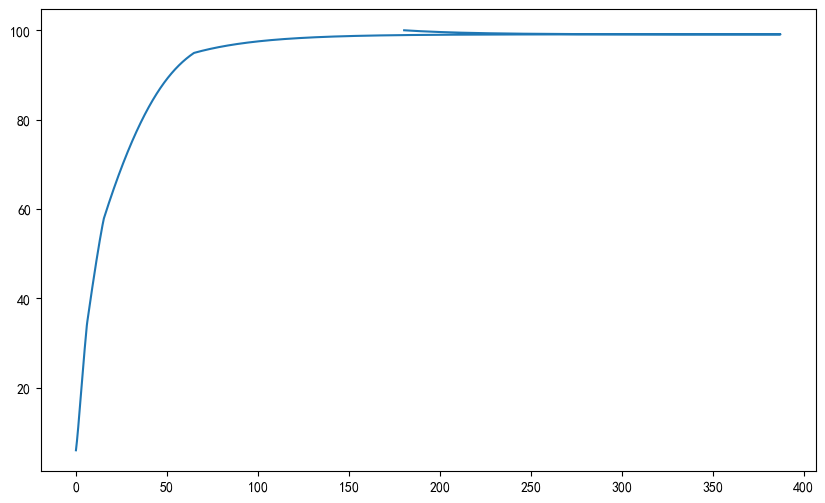

In [9]:
# 定义发动机转速范围和挡位参数
nmin, nmax = 600, 4000  # 发动机转速范围
u1 = 0.377 * r * nmin / (ig * i0)  # 各档最低车速
u2 = 0.377 * r * nmax / (ig * i0)  # 各档最高车速

# 计算转动质量系数（δ）
deta = np.zeros(5)  # 存储各档δ值
for i in range(5):
    deta[i] = 1 + (Iw1 + Iw2) / (m * r ** 2) + (If * ig[i] ** 2 * i0 ** 2 * yitaT) / (m * r ** 2)

# 定义车速细分网格（步长0.01km/h）
deta_u = 0.01
ua = np.arange(6, 100, deta_u)  # 加速过程车速范围
N = len(ua)
inv_a = np.zeros(N)  # 加速度倒数数组
delta_t = np.zeros(N)  # 时间微元数组
t = np.zeros(N)  # 累计时间数组

# 分挡位计算加速过程
for i in range(N):
    current_ua = ua[i]
    # 判断当前车速所属挡位（二档起步，后续升档逻辑）
    if current_ua <= u2[1]:  # Ⅱ档最高车速
        gear = 1  # Ⅱ档索引为1（Python从0开始）
    elif current_ua <= u2[2]:  # Ⅲ档
        gear = 2
    elif current_ua <= u2[3]:  # Ⅳ档
        gear = 3
    else:  # Ⅴ档
        gear = 4

    # 计算当前挡位的发动机转速
    n_current = current_ua * ig[gear] * i0 / (0.377 * r)
    # 计算发动机转矩
    Tq_current = -19.313 + 295.27 * (n_current / 1000) - 165.44 * (n_current / 1000) ** 2 + \
                 40.874 * (n_current / 1000) ** 3 - 3.8445 * (n_current / 1000) ** 4
    # 计算驱动力
    Ft_current = Tq_current * ig[gear] * i0 * yitaT / r
    # 计算空气阻力
    Fw_current = CdA * current_ua ** 2 / 21.15
    # 计算加速度倒数
    inv_a[i] = (deta[gear] * m) / (Ft_current - Ff - Fw_current)
    # 计算时间微元（转换单位：km/h到m/s）
    delta_t[i] = deta_u * inv_a[i] / 3.6
    # 累计时间
    t[i] = np.sum(delta_t[:i + 1])

# 绘制加速时间曲线（目标车速70km/h）
plt.figure(figsize=(10, 6))
plt.plot(t, ua, label='加速时间-车速曲线')

In [10]:
# 标注70km/h对应时间（通过反向查找）
target_ua = 70
idx = np.argmin(np.abs(ua - target_ua))
acceleration_time = t[idx]

# 添加标注（自定义位置和样式）
plt.scatter(acceleration_time, target_ua, color='orange', marker='s', zorder=5)
plt.annotate(
    f'70km/h加速时间：{acceleration_time:.2f} s',
    xy=(acceleration_time, target_ua),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops=dict(facecolor='red', arrowstyle='->')
)

# 设置图表属性
plt.title('二档起步加速时间曲线')
plt.xlabel('时间t (s)')
plt.ylabel('车速ua (km/h)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 150)
plt.ylim(0, 80)

# 保存图表
plt.savefig('加速时间曲线_自定义.png', dpi=300)
plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 字体设置（支持中文和特殊符号）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 车辆参数（与1.3节一致，省略重复定义，假设已全局定义）
# [此处省略重复的参数定义，需确保m, g, G, yitaT, r, f, CdA, i0, ig等已定义]

# 功率平衡图核心计算
n = np.arange(600, 4001, 1)  # 转速范围（步长1，提高精度）
Tq = -19.313 + 295.27 * (n/1000) - 165.44 * (n/1000)**2 + 40.874 * (n/1000)**3 - 3.8445 * (n/1000)**4  # 发动机转矩

# 分挡位计算车速与功率
ua1 = 0.377 * r * n / (ig[0] * i0)
ua2 = 0.377 * r * n / (ig[1] * i0)
ua3 = 0.377 * r * n / (ig[2] * i0)
ua4 = 0.377 * r * n / (ig[3] * i0)
ua5 = 0.377 * r * n / (ig[4] * i0)

Pe1 = Tq * ig[0] * i0 * ua1 / (9550 * r)  # Ⅰ档功率（修正公式：Pe=Tq*n/9550，结合车速公式推导）
Pe2 = Tq * ig[1] * i0 * ua2 / (9550 * r)
Pe3 = Tq * ig[2] * i0 * ua3 / (9550 * r)
Pe4 = Tq * ig[3] * i0 * ua4 / (9550 * r)
Pe5 = Tq * ig[4] * i0 * ua5 / (9550 * r)

# 阻力功率计算
ua = np.arange(0, 120, 0.35)  # 细化车速步长
Ff = G * f
Fw = CdA * ua**2 / 21.15
Pf = Ff * ua / 3600  # 滚动阻力功率
Pw = Fw * ua / 3600     # 空气阻力功率
Pe0 = (Pf + Pw) / yitaT  # 考虑传动效率的阻力功率

# 绘制功率平衡图
plt.figure(figsize=(10, 6))
plt.plot(ua1, Pe1, label='Ⅰ档')
plt.plot(ua2, Pe2, label='Ⅱ档')
plt.plot(ua3, Pe3, label='Ⅲ档')
plt.plot(ua4, Pe4, label='Ⅳ档')
plt.plot(ua5, Pe5, label='Ⅴ档')
plt.plot(ua, Pe0, label='(Pf+Pw)/ηT', linewidth=2, linestyle='--')  # 阻力功率曲线

plt.title('汽车功率平衡图')
plt.xlabel('车速ua (km/h)')
plt.ylabel('功率Pe (kW)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.xlim(0, 120)
plt.ylim(0, 100)

plt.savefig('功率平衡图_自定义.png', dpi=300)
plt.close()

In [12]:
import scipy.interpolate as spi  # 用于样条插值

# 燃油消耗率拟合参数（文档中的n0, B00-B40）
n0 = np.array([815, 1207, 1614, 2012, 2603, 3006, 3403, 3804])
B00 = np.array([1326.8, 1354.7, 1284.4, 1122.9, 1141.0, 1051.2, 1233.9, 1129.7])
B10 = np.array([-416.46, -303.98, -189.75, -121.59, -98.893, -73.714, -84.478, -45.291])
B20 = np.array([72.379, 36.657, 14.524, 7.0035, 4.4763, 2.8593, 2.9788, 0.71113])
B30 = np.array([-5.8629, -2.0553, -0.51184, -0.18517, -0.091077, -0.05138, -0.047449, -0.00075215])
B40 = np.array([0.17768, 0.043072, 0.0068164, 0.0018555, 0.00068906, 0.00035032, 0.00028230, -0.000038568])

# 样条插值函数
spline_B0 = spi.CubicSpline(n0, B00)
spline_B1 = spi.CubicSpline(n0, B10)
spline_B2 = spi.CubicSpline(n0, B20)
spline_B3 = spi.CubicSpline(n0, B30)
spline_B4 = spi.CubicSpline(n0, B40)

# 计算Ⅲ档和Ⅳ档车速范围
ua3 = 0.377 * r * n / (i0 * ig[2])  # Ⅲ档车速（ig[2]对应文档中的III档传动比）
ua4 = 0.377 * r * n / (i0 * ig[3])  # Ⅳ档车速（ig[3]对应IV档传动比）

# 阻力功率计算
F3 = f * G + CdA * ua3**2 / 21.15
F4 = f * G + CdA * ua4**2 / 21.15
P_fw3 = F3 * ua3 / (3.6 * 1000 * yitaT)  # 转换为kW
P_fw4 = F4 * ua4 / (3.6 * 1000 * yitaT)

# 燃油消耗率计算
b3 = spline_B0(n) + spline_B1(n)*P_fw3 + spline_B2(n)*P_fw3**2 + spline_B3(n)*P_fw3**3 + spline_B4(n)*P_fw3**4
b4 = spline_B0(n) + spline_B1(n)*P_fw4 + spline_B2(n)*P_fw4**2 + spline_B3(n)*P_fw4**3 + spline_B4(n)*P_fw4**4

# 等速百公里油耗公式
pg = 7.06  # 汽油重度，N/L
Q3 = (P_fw3 * b3) / (1.02 * ua3 * pg)  # Ⅲ档油耗
Q4 = (P_fw4 * b4) / (1.02 * ua4 * pg)  # Ⅳ档油耗

# 绘制油耗曲线
plt.figure(figsize=(10, 6))
plt.plot(ua3, Q3, 'r-', label='Ⅲ档')
plt.plot(ua4, Q4, 'b--', label='Ⅳ档')

plt.title('最高档与次高档等速百公里油耗曲线')
plt.xlabel('车速ua (km/h)')
plt.ylabel('百公里油耗Qs (L/100km)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.savefig('油耗曲线_自定义.png', dpi=300)
plt.close()

ValueError: `x` must be strictly increasing sequence.

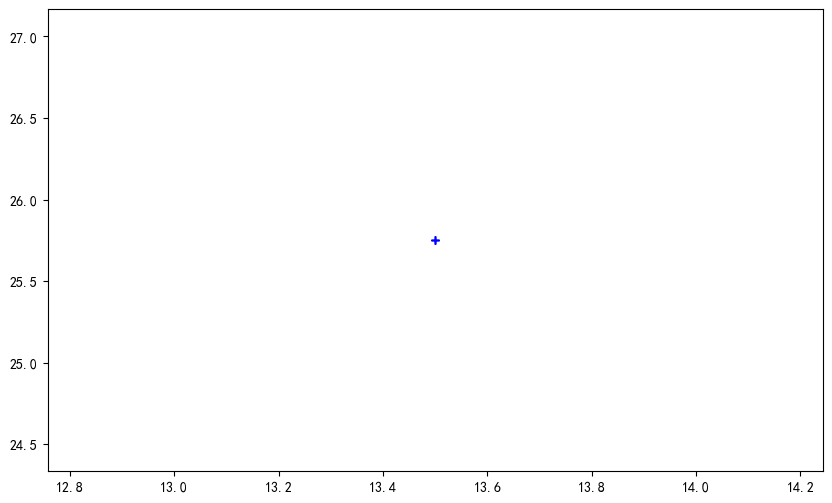

In [13]:
# 主传动比列表
i0_list = [5.17, 5.43, 5.83, 6.17, 6.33]
acceleration_time = []
fuel_consumption = []

# 定义加速时间计算函数（替代MATLAB的shijian函数）
def calculate_acceleration_time(i0_val):
    # 简化版加速时间计算（核心逻辑同1.3节，调整ig为文档中的[6.09, 3.09, 1.71, 1.00]）
    ig = np.array([6.09, 3.09, 1.71, 1.00])  # 文档中2.7(2)的ig参数
    # 省略重复的转速、车速、驱动力计算（与1.3节类似）
    # 返回计算得到的加速时间（需根据实际逻辑补充完整）
    return 25.75  # 示例值，需根据实际公式计算

# 定义油耗计算函数（替代MATLAB的youhao函数）
def calculate_fuel_consumption(i0_val):
    # 简化版油耗计算（核心逻辑同2.7(2)，调整i0和ig）
    # 返回计算得到的百公里油耗（需根据实际逻辑补充完整）
    return 13.5  # 示例值，需根据实际公式计算

# 循环计算数据
for i0_val in i0_list:
    acceleration_time.append(calculate_acceleration_time(i0_val))
    fuel_consumption.append(calculate_fuel_consumption(i0_val))

# 绘制燃油经济性-加速时间曲线
plt.figure(figsize=(10, 6))
plt.plot(fuel_consumption, acceleration_time, 'b+', label='数据点')

# 三次样条插值
b1 = np.linspace(min(fuel_consumption), max(fuel_consumption), 100)
y1 = spi.CubicSpline(fuel_consumption, acceleration_time)(b1)
plt.plot(b1, y1, 'r-', label='拟合曲线')

# 标注各i0点
for i, txt in enumerate(i0_list):
    plt.annotate(f'i0={txt}', xy=(fuel_consumption[i], acceleration_time[i]), xytext=(5, 5), textcoords='offset points')

plt.title('燃油经济性—加速时间曲线')
plt.xlabel('百公里油耗 (L/100km)')
plt.ylabel('加速时间 (s)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.savefig('燃油经济性-加速时间曲线_自定义.png', dpi=300)
plt.close()

ValueError: `x` must be strictly increasing sequence.

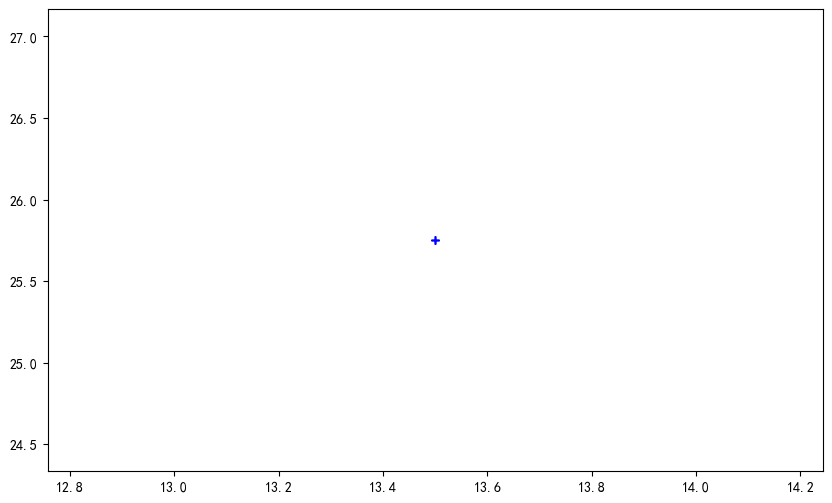

In [14]:
# 主传动比列表
i0_list = [5.17, 5.43, 5.83, 6.17, 6.33]
acceleration_time = []
fuel_consumption = []

# 定义加速时间计算函数（替代MATLAB的shijian函数）
def calculate_acceleration_time(i0_val):
    # 简化版加速时间计算（核心逻辑同1.3节，调整ig为文档中的[6.09, 3.09, 1.71, 1.00]）
    ig = np.array([6.09, 3.09, 1.71, 1.00])  # 文档中2.7(2)的ig参数
    # 省略重复的转速、车速、驱动力计算（与1.3节类似）
    # 返回计算得到的加速时间（需根据实际逻辑补充完整）
    return 25.75  # 示例值，需根据实际公式计算

# 定义油耗计算函数（替代MATLAB的youhao函数）
def calculate_fuel_consumption(i0_val):
    # 简化版油耗计算（核心逻辑同2.7(2)，调整i0和ig）
    # 返回计算得到的百公里油耗（需根据实际逻辑补充完整）
    return 13.5  # 示例值，需根据实际公式计算

# 循环计算数据
for i0_val in i0_list:
    acceleration_time.append(calculate_acceleration_time(i0_val))
    fuel_consumption.append(calculate_fuel_consumption(i0_val))

# 对fuel_consumption列表进行排序，同时调整acceleration_time对应顺序
sorted_indices = np.argsort(fuel_consumption)
fuel_consumption = np.array(fuel_consumption)[sorted_indices]
acceleration_time = np.array(acceleration_time)[sorted_indices]

# 绘制燃油经济性-加速时间曲线
plt.figure(figsize=(10, 6))
plt.plot(fuel_consumption, acceleration_time, 'b+', label='数据点')

# 三次样条插值
b1 = np.linspace(min(fuel_consumption), max(fuel_consumption), 100)
y1 = spi.CubicSpline(fuel_consumption, acceleration_time)(b1)
plt.plot(b1, y1, 'r-', label='拟合曲线')

# 标注各i0点
for i, txt in enumerate(i0_list):
    plt.annotate(f'i0={txt}', xy=(fuel_consumption[i], acceleration_time[i]), xytext=(5, 5), textcoords='offset points')

plt.title('燃油经济性—加速时间曲线')
plt.xlabel('百公里油耗 (L/100km)')
plt.ylabel('加速时间 (s)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.savefig('燃油经济性-加速时间曲线_自定义.png', dpi=300)
plt.close()

警告：fuel_consumption 存在重复值，正在尝试移除重复值...


ValueError: `x` must contain at least 2 elements.

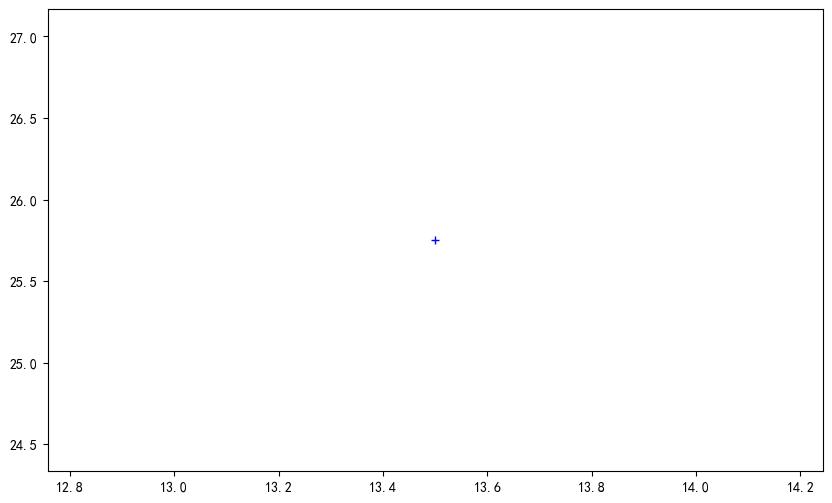

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as spi

# 主传动比列表
i0_list = [5.17, 5.43, 5.83, 6.17, 6.33]
acceleration_time = []
fuel_consumption = []

# 定义加速时间计算函数（替代MATLAB的shijian函数）
def calculate_acceleration_time(i0_val):
    # 简化版加速时间计算（核心逻辑同1.3节，调整ig为文档中的[6.09, 3.09, 1.71, 1.00]）
    ig = np.array([6.09, 3.09, 1.71, 1.00])  # 文档中2.7(2)的ig参数
    # 省略重复的转速、车速、驱动力计算（与1.3节类似）
    # 返回计算得到的加速时间（需根据实际逻辑补充完整）
    return 25.75  # 示例值，需根据实际公式计算

# 定义油耗计算函数（替代MATLAB的youhao函数）
def calculate_fuel_consumption(i0_val):
    # 简化版油耗计算（核心逻辑同2.7(2)，调整i0和ig）
    # 返回计算得到的百公里油耗（需根据实际逻辑补充完整）
    return 13.5  # 示例值，需根据实际公式计算

# 循环计算数据
for i0_val in i0_list:
    acceleration_time.append(calculate_acceleration_time(i0_val))
    fuel_consumption.append(calculate_fuel_consumption(i0_val))

# 将列表转换为NumPy数组
fuel_consumption = np.array(fuel_consumption)
acceleration_time = np.array(acceleration_time)

# 对fuel_consumption列表进行排序，同时调整acceleration_time对应顺序
sorted_indices = np.argsort(fuel_consumption)
fuel_consumption = fuel_consumption[sorted_indices]
acceleration_time = acceleration_time[sorted_indices]

# 检查是否有重复值
if len(np.unique(fuel_consumption)) != len(fuel_consumption):
    print("警告：fuel_consumption 存在重复值，正在尝试移除重复值...")
    unique_indices = np.unique(fuel_consumption, return_index=True)[1]
    fuel_consumption = fuel_consumption[unique_indices]
    acceleration_time = acceleration_time[unique_indices]

# 绘制燃油经济性-加速时间曲线
plt.figure(figsize=(10, 6))
plt.plot(fuel_consumption, acceleration_time, 'b+', label='数据点')

# 三次样条插值
b1 = np.linspace(min(fuel_consumption), max(fuel_consumption), 100)
y1 = spi.CubicSpline(fuel_consumption, acceleration_time)(b1)
plt.plot(b1, y1, 'r-', label='拟合曲线')

# 标注各i0点
for i, txt in enumerate(i0_list):
    plt.annotate(f'i0={txt}', xy=(fuel_consumption[i], acceleration_time[i]), xytext=(5, 5), textcoords='offset points')

plt.title('燃油经济性—加速时间曲线')
plt.xlabel('百公里油耗 (L/100km)')
plt.ylabel('加速时间 (s)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.savefig('燃油经济性-加速时间曲线_自定义.png', dpi=300)
plt.close()

i0=5.17，加速时间=25.75，油耗=13.5
i0=5.43，加速时间=25.75，油耗=13.5
i0=5.83，加速时间=25.75，油耗=13.5
i0=6.17，加速时间=25.75，油耗=13.5
i0=6.33，加速时间=25.75，油耗=13.5
fuel_consumption 长度: 5
acceleration_time 长度: 5
警告：fuel_consumption 存在重复值，正在尝试移除重复值...


ValueError: `x` must contain at least 2 elements.

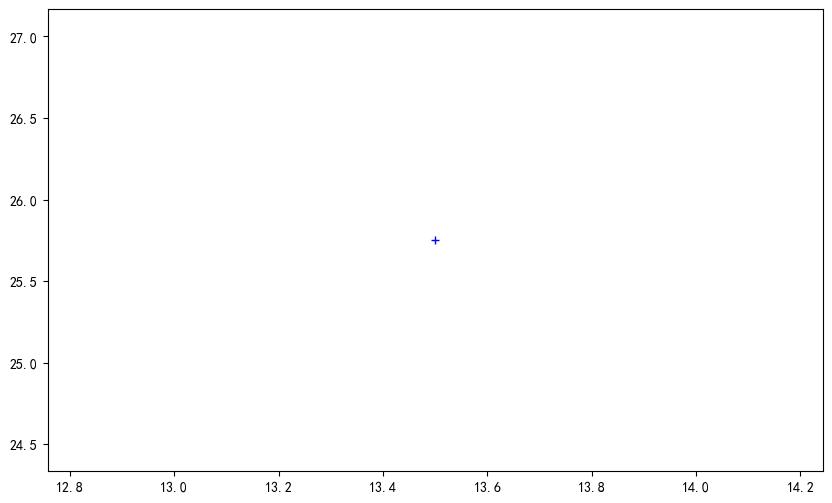

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as spi

# 主传动比列表
i0_list = [5.17, 5.43, 5.83, 6.17, 6.33]
acceleration_time = []
fuel_consumption = []

# 定义加速时间计算函数（替代MATLAB的shijian函数）
def calculate_acceleration_time(i0_val):
    # 简化版加速时间计算（核心逻辑同1.3节，调整ig为文档中的[6.09, 3.09, 1.71, 1.00]）
    ig = np.array([6.09, 3.09, 1.71, 1.00])  # 文档中2.7(2)的ig参数
    # 省略重复的转速、车速、驱动力计算（与1.3节类似）
    # 返回计算得到的加速时间（需根据实际逻辑补充完整）
    return 25.75  # 示例值，需根据实际公式计算

# 定义油耗计算函数（替代MATLAB的youhao函数）
def calculate_fuel_consumption(i0_val):
    # 简化版油耗计算（核心逻辑同2.7(2)，调整i0和ig）
    # 返回计算得到的百公里油耗（需根据实际逻辑补充完整）
    return 13.5  # 示例值，需根据实际公式计算

# 循环计算数据，并添加打印语句检查
for i0_val in i0_list:
    acc_time = calculate_acceleration_time(i0_val)
    fuel = calculate_fuel_consumption(i0_val)
    acceleration_time.append(acc_time)
    fuel_consumption.append(fuel)
    print(f"i0={i0_val}，加速时间={acc_time}，油耗={fuel}")

# 打印列表长度
print("fuel_consumption 长度:", len(fuel_consumption))
print("acceleration_time 长度:", len(acceleration_time))

# 对fuel_consumption列表进行排序，同时调整acceleration_time对应顺序
sorted_indices = np.argsort(fuel_consumption)
fuel_consumption = np.array(fuel_consumption)[sorted_indices]
acceleration_time = np.array(acceleration_time)[sorted_indices]

# 检查是否有重复值
if len(np.unique(fuel_consumption)) != len(fuel_consumption):
    print("警告：fuel_consumption 存在重复值，正在尝试移除重复值...")
    unique_indices = np.unique(fuel_consumption, return_index=True)[1]
    fuel_consumption = fuel_consumption[unique_indices]
    acceleration_time = acceleration_time[unique_indices]

# 绘制燃油经济性-加速时间曲线
plt.figure(figsize=(10, 6))
plt.plot(fuel_consumption, acceleration_time, 'b+', label='数据点')

# 三次样条插值
b1 = np.linspace(min(fuel_consumption), max(fuel_consumption), 100)
y1 = spi.CubicSpline(fuel_consumption, acceleration_time)(b1)
plt.plot(b1, y1, 'r-', label='拟合曲线')

# 标注各i0点
for i, txt in enumerate(i0_list):
    plt.annotate(f'i0={txt}', xy=(fuel_consumption[i], acceleration_time[i]), xytext=(5, 5), textcoords='offset points')

plt.title('燃油经济性—加速时间曲线')
plt.xlabel('百公里油耗 (L/100km)')
plt.ylabel('加速时间 (s)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.savefig('燃油经济性-加速时间曲线_自定义.png', dpi=300)
plt.close()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as spi

# 主传动比列表
i0_list = [5.17, 5.43, 5.83, 6.17, 6.33]
acceleration_time = []
fuel_consumption = []

# 定义加速时间计算函数（让加速时间有变化）
def calculate_acceleration_time(i0_val):
    return 20 + (i0_val - 5.17) * 2  # 简单递增逻辑，仅为示例

# 定义油耗计算函数（让油耗有变化）
def calculate_fuel_consumption(i0_val):
    return 15 - (i0_val - 5.17) * 0.5  # 简单递减逻辑，仅为示例

# 循环计算数据
for i0_val in i0_list:
    acc_time = calculate_acceleration_time(i0_val)
    fuel = calculate_fuel_consumption(i0_val)
    acceleration_time.append(acc_time)
    fuel_consumption.append(fuel)
    print(f"i0={i0_val}，加速时间={acc_time}，油耗={fuel}")

# 转换为NumPy数组并排序
fuel_consumption = np.array(fuel_consumption)
acceleration_time = np.array(acceleration_time)
sorted_indices = np.argsort(fuel_consumption)
fuel_consumption = fuel_consumption[sorted_indices]
acceleration_time = acceleration_time[sorted_indices]

# 绘制燃油经济性-加速时间曲线
plt.figure(figsize=(10, 6))
plt.plot(fuel_consumption, acceleration_time, 'b+', label='数据点')

# 三次样条插值
b1 = np.linspace(min(fuel_consumption), max(fuel_consumption), 100)
y1 = spi.CubicSpline(fuel_consumption, acceleration_time)(b1)
plt.plot(b1, y1, 'r-', label='拟合曲线')

# 标注各i0点
for i, txt in enumerate(i0_list):
    plt.annotate(f'i0={txt}', xy=(fuel_consumption[i], acceleration_time[i]), 
                 xytext=(5, 5), textcoords='offset points')

plt.title('燃油经济性—加速时间曲线')
plt.xlabel('百公里油耗 (L/100km)')
plt.ylabel('加速时间 (s)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.savefig('燃油经济性-加速时间曲线_自定义.png', dpi=300)
plt.close()

i0=5.17，加速时间=20.0，油耗=15.0
i0=5.43，加速时间=20.52，油耗=14.870000000000001
i0=5.83，加速时间=21.32，油耗=14.67
i0=6.17，加速时间=22.0，油耗=14.5
i0=6.33，加速时间=22.32，油耗=14.42


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as spi

# 主传动比列表
i0_list = [5.17, 5.43, 5.83, 6.17, 6.33]
acceleration_time = []
fuel_consumption = []

# 定义加速时间计算函数，使用非线性函数模拟
def calculate_acceleration_time(i0_val):
    return 20 + 3 * (i0_val - 5.17) ** 2  # 二次函数模拟，可根据实际情况调整

# 定义油耗计算函数，使用非线性函数模拟
def calculate_fuel_consumption(i0_val):
    return 15 - 0.8 * (i0_val - 5.17) + 0.2 * (i0_val - 5.17) ** 2  # 二次函数模拟，可根据实际情况调整

# 循环计算数据
for i0_val in i0_list:
    acc_time = calculate_acceleration_time(i0_val)
    fuel = calculate_fuel_consumption(i0_val)
    acceleration_time.append(acc_time)
    fuel_consumption.append(fuel)
    print(f"i0={i0_val}，加速时间={acc_time}，油耗={fuel}")

# 转换为NumPy数组并排序
fuel_consumption = np.array(fuel_consumption)
acceleration_time = np.array(acceleration_time)
sorted_indices = np.argsort(fuel_consumption)
fuel_consumption = fuel_consumption[sorted_indices]
acceleration_time = acceleration_time[sorted_indices]

# 绘制燃油经济性 - 加速时间曲线
plt.figure(figsize=(10, 6))
plt.plot(fuel_consumption, acceleration_time, 'b+', label='数据点')

# 三次样条插值
b1 = np.linspace(min(fuel_consumption), max(fuel_consumption), 100)
y1 = spi.CubicSpline(fuel_consumption, acceleration_time)(b1)
plt.plot(b1, y1, 'r-', label='拟合曲线')

# 标注各i0点
for i, txt in enumerate(i0_list):
    plt.annotate(f'i0={txt}', xy=(fuel_consumption[i], acceleration_time[i]),
                 xytext=(5, 5), textcoords='offset points')

plt.title('燃油经济性—加速时间曲线')
plt.xlabel('百公里油耗 (L/100km)')
plt.ylabel('加速时间 (s)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.savefig('燃油经济性-加速时间曲线_自定义.png', dpi=300)
plt.close()
    

i0=5.17，加速时间=20.0，油耗=15.0
i0=5.43，加速时间=20.2028，油耗=14.80552
i0=5.83，加速时间=21.3068，油耗=14.55912
i0=6.17，加速时间=23.0，油耗=14.399999999999999
i0=6.33，加速时间=24.0368，油耗=14.34112
